# GBM and Monte Carlo Option Pricing

This notebook uses geometric Brownian motion (GBM) to simulate asset prices under the risk-neutral measure. It validates a Monte Carlo estimate against the analytical Black–Scholes price and then applies the same simulation framework to a path-dependent arithmetic-average Asian call.

The simulation and pricing logic is implemented as reusable functions under `src/`; this notebook focuses on numerical validation and interpretation.

## 1. Setup

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt

from src.yieldcurve import YieldCurve
from src.derivatives import EuropeanCall
from src.gbm import simulate_paths, simulate_terminal_prices
from src.monte_carlo import (
    european_call_payoff,
    price_arithmetic_asian_call,
    price_european_option,
)

## 2. Model parameters

Under the risk-neutral measure, GBM is written as

\[
dS_t = rS_t\,dt + \sigma S_t\,dW_t,
\]

so the expected continuously compounded growth rate used for valuation is the risk-free rate rather than an investor's forecast of the asset's return.

In [2]:
S0 = 100.0
K = 100.0
T = 1.0
sigma = 0.20

maturities = [0.5, 1.0, 2.0, 3.0]
zero_rates = [0.03, 0.032, 0.035, 0.038]
yield_curve = YieldCurve(maturities, zero_rates)
r = yield_curve.get_zero_rate(T)

print(f"Risk-free rate at T={T:.1f}: {r:.2%}")

Risk-free rate at T=1.0: 3.20%


## 3. Simulate GBM price paths

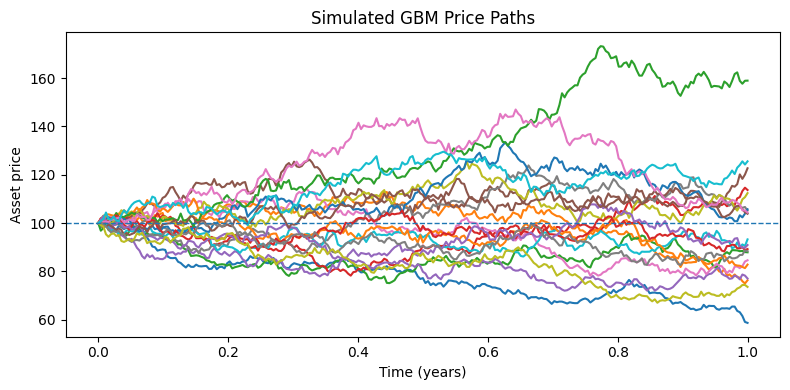

In [3]:
sample_paths = simulate_paths(
    S0=S0,
    drift=r,
    sigma=sigma,
    T=T,
    n_steps=252,
    n_simulations=20,
    rng=np.random.default_rng(7),
)

time_grid = np.linspace(0.0, T, sample_paths.shape[1])

plt.figure(figsize=(8, 4))
plt.plot(time_grid, sample_paths.T)
plt.axhline(S0, linestyle='--', linewidth=1)
plt.title("Simulated GBM Price Paths")
plt.xlabel("Time (years)")
plt.ylabel("Asset price")
plt.tight_layout()
plt.show()

The paths share the same initial value but diverge as random shocks accumulate. GBM keeps prices positive because normally distributed log returns are exponentiated into price levels.

## 4. Validate the terminal-price distribution

In [4]:
terminal_prices = simulate_terminal_prices(
    S0=S0,
    drift=r,
    sigma=sigma,
    T=T,
    n_simulations=200_000,
    rng=np.random.default_rng(21),
    antithetic=True,
)

simulated_mean = terminal_prices.mean()
theoretical_mean = S0 * np.exp(r * T)
relative_error = (simulated_mean - theoretical_mean) / theoretical_mean

print(f"Simulated mean terminal price:   {simulated_mean:.4f}")
print(f"Theoretical mean terminal price: {theoretical_mean:.4f}")
print(f"Relative error:                  {relative_error:.4%}")

Simulated mean terminal price:   103.2469
Theoretical mean terminal price: 103.2518
Relative error:                  -0.0047%


The simulated mean terminal price should be close to \(S_0e^{rT}\). This provides a direct check that the drift adjustment and exact GBM transition have been implemented consistently.

## 5. Price a European call by Monte Carlo

In [5]:
black_scholes_price = EuropeanCall(
    S0=S0,
    K=K,
    T=T,
    sigma=sigma,
    yield_curve=yield_curve,
).price()

mc_estimate = price_european_option(
    S0=S0,
    K=K,
    r=r,
    sigma=sigma,
    T=T,
    n_simulations=200_000,
    payoff=european_call_payoff,
    rng=np.random.default_rng(42),
    antithetic=True,
)

lower, upper = mc_estimate.confidence_interval

print(f"Black–Scholes price: {black_scholes_price:.4f}")
print(f"Monte Carlo price:   {mc_estimate.price:.4f}")
print(f"Standard error:      {mc_estimate.standard_error:.4f}")
print(f"95% confidence interval: [{lower:.4f}, {upper:.4f}]")

Black–Scholes price: 9.5146
Monte Carlo price:   9.5388
Standard error:      0.0319
95% confidence interval: [9.4763, 9.6013]


The analytical price provides a benchmark for the simulation. A Monte Carlo estimate inside a narrow confidence interval around the Black–Scholes value indicates that the risk-neutral terminal distribution, payoff and discounting steps are working together correctly.

## 6. Examine Monte Carlo convergence

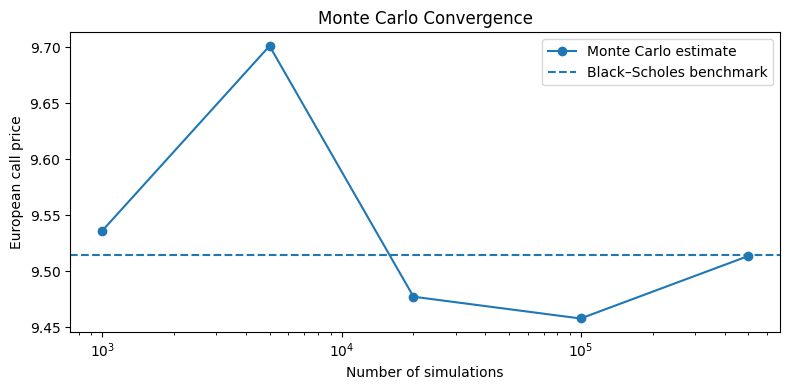

n=  1,000 | price=9.5365 | standard error=0.4430
n=  5,000 | price=9.7014 | standard error=0.1995
n= 20,000 | price=9.4774 | standard error=0.0996
n=100,000 | price=9.4579 | standard error=0.0445
n=500,000 | price=9.5135 | standard error=0.0200


In [6]:
simulation_counts = [1_000, 5_000, 20_000, 100_000, 500_000]
mc_prices = []
standard_errors = []

for i, n_simulations in enumerate(simulation_counts):
    estimate = price_european_option(
        S0=S0,
        K=K,
        r=r,
        sigma=sigma,
        T=T,
        n_simulations=n_simulations,
        payoff=european_call_payoff,
        rng=np.random.default_rng(100 + i),
        antithetic=True,
    )
    mc_prices.append(estimate.price)
    standard_errors.append(estimate.standard_error)

plt.figure(figsize=(8, 4))
plt.semilogx(simulation_counts, mc_prices, marker='o', label='Monte Carlo estimate')
plt.axhline(black_scholes_price, linestyle='--', label='Black–Scholes benchmark')
plt.title("Monte Carlo Convergence")
plt.xlabel("Number of simulations")
plt.ylabel("European call price")
plt.legend()
plt.tight_layout()
plt.show()

for n_simulations, price, se in zip(simulation_counts, mc_prices, standard_errors):
    print(
        f"n={n_simulations:>7,} | price={price:.4f} | "
        f"standard error={se:.4f}"
    )

Increasing the number of simulations reduces sampling uncertainty at the expected square-root rate. The estimate does not move monotonically toward the benchmark, but its standard error contracts as the sample grows.

## 7. Price a path-dependent Asian call

In [7]:
asian_estimate = price_arithmetic_asian_call(
    S0=S0,
    K=K,
    r=r,
    sigma=sigma,
    T=T,
    n_steps=52,
    n_simulations=100_000,
    rng=np.random.default_rng(123),
)

asian_lower, asian_upper = asian_estimate.confidence_interval

print(f"European call price: {black_scholes_price:.4f}")
print(f"Asian call price:    {asian_estimate.price:.4f}")
print(
    "Asian 95% confidence interval: "
    f"[{asian_lower:.4f}, {asian_upper:.4f}]"
)

European call price: 9.5146
Asian call price:    5.3746
Asian 95% confidence interval: [5.3262, 5.4230]


The arithmetic-average Asian call is cheaper in this example because averaging the asset price over time reduces the variance of the payoff relative to using only the terminal price. Unlike the European option, this contract is path dependent and does not have the same simple Black–Scholes closed form, making simulation a natural pricing method.

## 8. Findings

- Exact GBM simulation produces a terminal mean consistent with the risk-neutral expectation.
- Monte Carlo pricing converges toward the analytical Black–Scholes value as the simulation count increases.
- Confidence intervals quantify the sampling uncertainty that remains in a simulation-based estimate.
- Reusing the GBM path generator makes it straightforward to price a path-dependent arithmetic-average Asian call.

A natural next extension is to invert observed option prices for implied volatility and then relax the constant-volatility assumption.